# Building a binary classifier model with PyTorch

This notebook address following steps:
- Build a `PyTorch` `Dataset`/`DataLoader` pipeline
- Build a small fully-connected neural network with `PyTorch`
- Build a training loop (with validation) with `PyTorch`
- Draw plots: training/validation loss, accuracy, ROC curve, and confusion matrix
- Save and load a model


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


# Data loadig and preprocessing

With `pandas` and `scikit-learn`

## Load data

There are multiple ways:



>### Method 1: import from the web (e.g. scikit-learn)
- Open Folder tree on the left sidebar of Google Colab
- Drag & Drop csv file from your HD to any folder
- Right clic on the file and copy the path.

In [2]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

>### Method 2: import from your PC
- Open Folder tree on the left sidebar of Google Colab
- Drag & Drop csv file from your HD to any folder
- Right clic on the file and copy the path.

In [3]:
# csv_path = "/content/cancer_dataset.csv"
# df = pd.read_csv(csv_path, index_col=0)

>### Method 3: import from your Google Drive
- mount your google drive so that it is binded with this notebook
- Put csv file somewhere in your drive
- Find the file in the left sidebar
- Right click on the file and copy the path

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

## Explore dataset, create input matrix and target values


In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


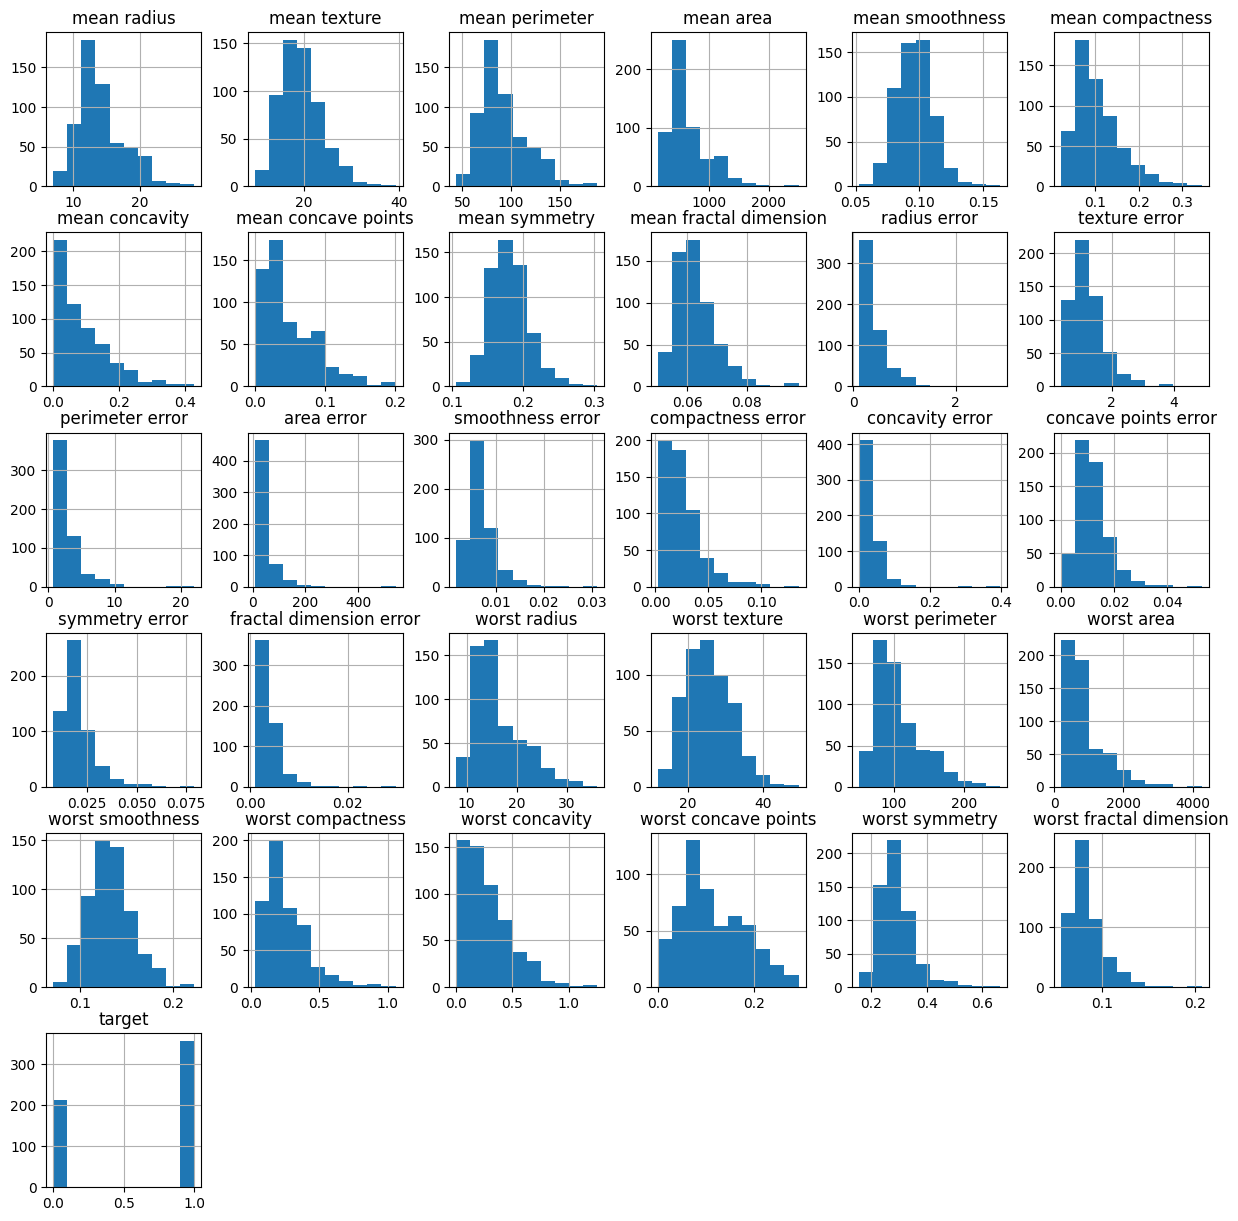

In [8]:
df.hist(figsize=(15, 15))
plt.show()

<Axes: xlabel='target', ylabel='count'>

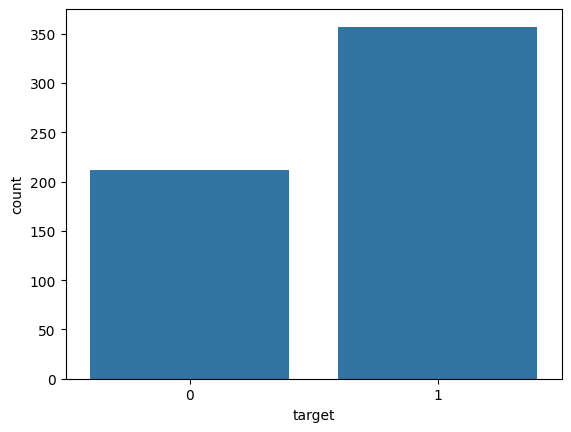

In [9]:
sns.countplot(x='target', data=df)

<Axes: >

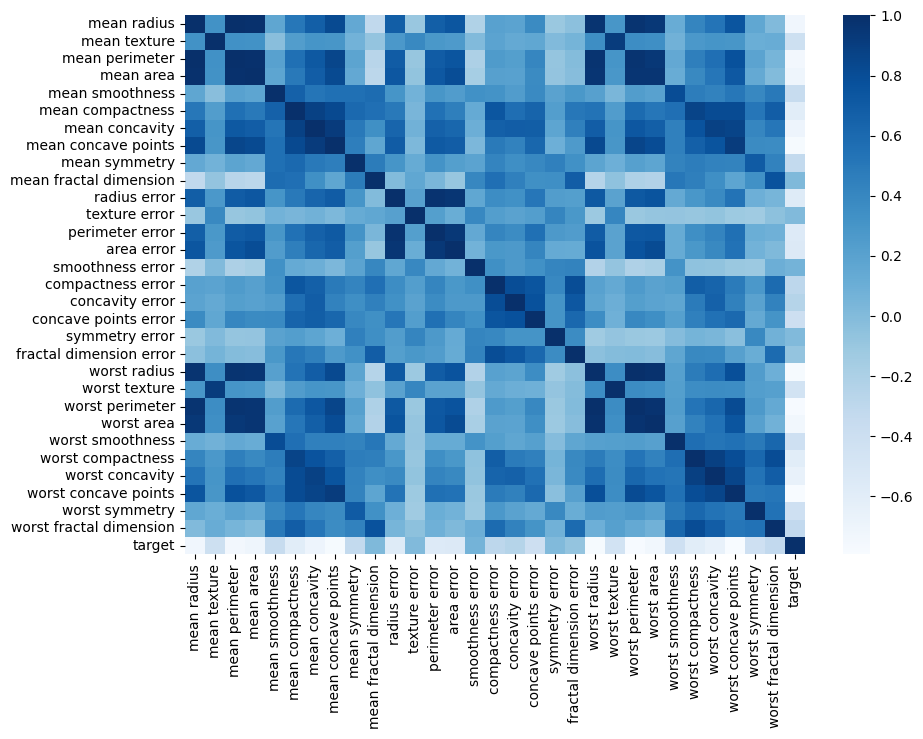

In [10]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), cmap='Blues')

- To work with Neural Networks, we can use `pandas` or `numpy`, but we will have to transform data into `torch.tensor` at some point.

In [11]:
# to numpy arrays
X = df.drop('target', axis=1).values
y = df['target'].values

print("X:", type(X), X.dtype)
print("y:", type(y), y.dtype)

X: <class 'numpy.ndarray'> float64
y: <class 'numpy.ndarray'> int64


## Data splitting

Split the data into training and test set (20% for the validation set)

We use random_state to make sure splitting contains the same data each time (= seed).

> Note: Although scikit-learn uses `train_test_split`, here we are actually splitting into
**training** and **validation** sets. The true **test set** is a separate dataset
(we won’t use it in this lab).


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE)

## Data transforming

Standardise the data (`x_standardised = (x - x_mean) / std_dev`)

In [13]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

sc = StandardScaler()

In [14]:
# we use exactly the scale set from the training set to transform the test set
# fit_transform : applies transformation and stores parameters (µ, sigma...)
# transform : uses the parameters just stored before to transform validation dataset
X_train = sc.fit_transform(X_train)
X_val = sc.transform(X_val)

In [15]:
X_train.shape

(455, 30)

In [16]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-1.440753,-0.435319,-1.362085,-1.139118,0.780573,0.718921,2.823135,-0.119150,1.092662,2.458173,...,-1.232861,-0.476309,-1.247920,-0.973968,0.722894,1.186732,4.672828,0.932012,2.097242,1.886450
1,1.974096,1.733026,2.091672,1.851973,1.319843,3.426275,2.013112,2.665032,2.127004,1.558396,...,2.173314,1.311279,2.081617,2.137405,0.761928,3.265601,1.928621,2.698947,1.891161,2.497838
2,-1.399982,-1.249622,-1.345209,-1.109785,-1.332645,-0.307355,-0.365558,-0.696502,1.930333,0.954379,...,-1.295284,-1.040811,-1.245220,-0.999715,-1.438693,-0.548564,-0.644911,-0.970239,0.597602,0.057894
3,-0.981797,1.416222,-0.982587,-0.866944,0.059390,-0.596788,-0.820203,-0.845115,0.313264,0.074041,...,-0.829197,1.593530,-0.873572,-0.742947,0.796624,-0.729392,-0.774950,-0.809483,0.798928,-0.134497
4,-1.117700,-1.010259,-1.125002,-0.965942,1.269511,-0.439002,-0.983341,-0.930600,3.394436,0.950213,...,-1.085129,-1.334616,-1.117138,-0.896549,-0.174876,-0.995079,-1.209146,-1.354582,1.033544,-0.205732


## 1) Create PyTorch Datasets and Loaders

Pytorch works with tensors. But it also provide tools to feed models with data.

 We will now use two essential classes from PyTorch's data utility module:

* `Dataset`: This is an abstract class representing a dataset. You can create your own custom dataset by inheriting from this class and implementing the `__len__` and `__getitem__` methods.

* `DataLoader`: This class wraps a `Dataset` and provides an iterable over the dataset. It allows you to easily iterate through the data in batches, shuffle the data, and load the data in parallel. This is crucial for efficient training of deep learning models.

In [17]:
from torch.utils.data import Dataset, DataLoader
import torch

class CancerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CancerDataset(X_train, y_train)
val_dataset = CancerDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

When you don't need any custom logic for loading or processing individual data samples, `TensorDataset` can be a useful generic alternative

In [18]:
from torch.utils.data import TensorDataset, DataLoader

Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
Xte = torch.tensor(X_val, dtype=torch.float32)
yte = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(Xte, yte), batch_size=64)

## 2) Building the model

In [19]:

class BCNet(nn.Module):
    def __init__(self, input_dim, hidden1=30, hidden2=15, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, 1)
        # self.dropout = nn.Dropout(dropout)  # course2

    def forward(self, x):
        x = F.relu(self.fc1(x))
        # x = self.dropout(x)   # course2
        x = F.relu(self.fc2(x))
        # x = self.dropout(x)   # course2
        return self.out(x)

nb_input_features = len(train_dataset[0][0])
model = BCNet(nb_input_features)
print(model)


BCNet(
  (fc1): Linear(in_features=30, out_features=30, bias=True)
  (fc2): Linear(in_features=30, out_features=15, bias=True)
  (out): Linear(in_features=15, out_features=1, bias=True)
)


## 3.a) Train the model - Basics

In chapter `3` we are going to build iteratively a training script for our model, with pytorch. We weill start with the core pytorch training loop. Then, in next iterations, we will add a little bit more complexity.

In [20]:
model = BCNet(nb_input_features)            # instanciate the model to reinitialize its weights
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, 50):                 # let's start with 100 epochs, for demonstratton.
    model.train()
    running_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()               # 1. reset gradients
        logits = model(x_batch)             # 2. forward pass
        loss = criterion(logits, y_batch)   # 3. compute loss
        loss.backward()                     # 4. backpropagation
        optimizer.step()                    # 5. update weights
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    if epoch == 1 or epoch % 5 == 0:
      print(f"Epoch {epoch}, Loss: {train_loss:.4f}")

Epoch 1, Loss: 0.7268
Epoch 5, Loss: 0.5385
Epoch 10, Loss: 0.2394
Epoch 15, Loss: 0.1125
Epoch 20, Loss: 0.0842
Epoch 25, Loss: 0.0785
Epoch 30, Loss: 0.0708
Epoch 35, Loss: 0.0617
Epoch 40, Loss: 0.0494
Epoch 45, Loss: 0.0439


## 3.b) Train the model - add `TensorBoard`

Printing Loss values in a cell output or in a terminal is not the best way to monitor trainings.

It's possible to record values in dictionnaries or lists, than to plot them. There is also an open-source library called [`TensorBoard`](https://www.tensorflow.org/tensorboard?hl=fr), which is dedicated for that. It provides a Web UI were we can observe training curves.

`TensorBoard` was originally created for `TensorFlow`, but `Pytorch` has its own [implementation](https://docs.pytorch.org/docs/stable//tensorboard.html).

Remark: our way to compute average loss was simple yet not the most accurate, because it divides sum of average losses by the number of batches. if the last batch is not full, it is biased. So let's use a more correct way to compute it.

In [21]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

writer = SummaryWriter(log_dir="./My_first_NN")         # TensorBoard writer instanciation. Writer will output to ./runs/ directory by default

model = BCNet(nb_input_features)
criterion = nn.BCEWithLogitsLoss()  # BCEWithLogitsLoss by default returns average of losses given a batch...
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in tqdm(range(1, 50)):
    model.train()
    running_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(x_batch)# ...So we need to multiply this value by the number of samples in the batch

    train_loss = running_loss / len(train_loader.dataset) # Divide by the total number of samples
    writer.add_scalar("Loss/train", train_loss, epoch)    # log to writer

writer.close()                                          # close writer after experiment to free memory.

100%|██████████| 49/49 [00:02<00:00, 23.69it/s]


In [22]:
# On Jupyter Notebbook or vscode:
# tensorboard --logdir=runs  # then go to --> http://localhost:6006

# on Google colab:
%load_ext tensorboard
%tensorboard --logdir "./My_first_NN"

## 3.c) Train the model - add evaluation step

Training log is not enough to ensure a model is well trained. We will see in next lecture, that one of the most important failure we want to prevent is called `overfitting`.

We thus have to keep an eye on `Loss`and other evaluation metrics from the `validation` dataset. Here, we will use the `test` dataset in the present example.

We first define a validation function apart from the training loop, to make the code more readable.

In [23]:
def evaluate_classification(model, loader, criterion):
    model.eval()
    losses, probs, trues = [], [], []

    with torch.inference_mode():
        for x_batch, y_batch in loader:
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item() * len(x_batch))

            batch_probs = torch.sigmoid(logits).squeeze(1).cpu().numpy() # we move from potential GPU tensor to CPU numpy array
            probs.extend(batch_probs)
            trues.extend(y_batch.squeeze(1).cpu().numpy())

    avg_loss = np.sum(losses) / len(loader.dataset)
    probs = np.array(probs)
    preds = (probs > 0.5).astype(int)
    trues = np.array(trues)

    return avg_loss, probs, preds, trues


Then we use this "generic" evaluation method in our code, to build the metrics we want.

In [24]:
from sklearn.metrics import accuracy_score
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

model = BCNet(nb_input_features)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

writer = SummaryWriter(log_dir="./My_first_NN")

for epoch in tqdm(range(1, 500)):
    model.train()
    running_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(x_batch)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_probs, val_preds, val_trues = evaluate_classification(model, val_loader, criterion) # new

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch) # new
    writer.add_scalar("Accuracy/val", accuracy_score(val_trues, val_preds), epoch) # new

writer.close()

100%|██████████| 499/499 [00:09<00:00, 52.90it/s]


Report to the TensorBoard and click "refresh".

## 3.d) Train the model - add manual plots

This is an example of graph handling by hand. It asks more code to write. There is no best choice (tensorboard vs manuel plots). It's up to the user, whether to use one method or the other.

In [25]:
model = BCNet(nb_input_features)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {'train_loss':[], 'val_loss':[], 'val_acc':[]}   # new

for epoch in tqdm(range(1, 500)):
    model.train()
    running_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(x_batch)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_probs, val_preds, val_trues = evaluate_classification(model, val_loader, criterion)

    history['train_loss'].append(train_loss)   # new
    history['val_loss'].append(val_loss)       # new
    history['val_acc'].append(accuracy_score(val_trues, (val_probs > 0.5).astype(int)))   # new


100%|██████████| 499/499 [00:06<00:00, 73.23it/s]


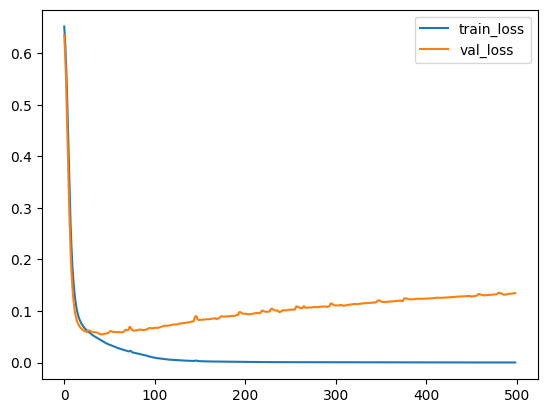

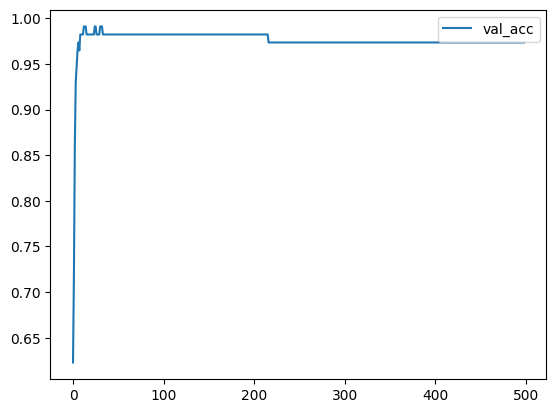

In [26]:
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
# plt.ylim(0, 0.1)
# plt.xlim(0, 200)
plt.legend(); plt.show()

plt.plot(history['val_acc'], label='val_acc')
plt.legend(); plt.show()

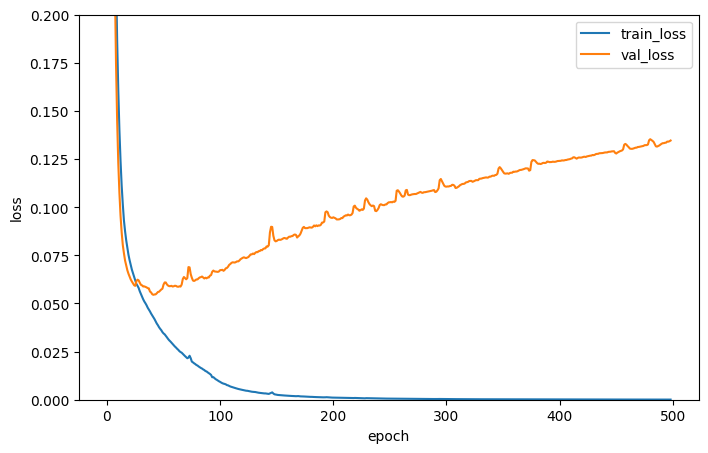

In [27]:
# seaborn version

import seaborn as sns
data = pd.DataFrame(history)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=data,
    x=data.index,
    y="train_loss",
    label="train_loss"
)
sns.lineplot(
    data=data,
    x=data.index,
    y="val_loss",
    label="val_loss"
)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.ylim(0, 0.2)
plt.legend()
plt.show()

## 4) Evaluate on test dataset

> **Side note** : in real life, we use a **test** dataset to measure model performance with real data. As we do not have such data, we will use the **validation** dataset instead. But this is a **BAD PRACTICE**.

Test Accuracy: 0.9736842105263158


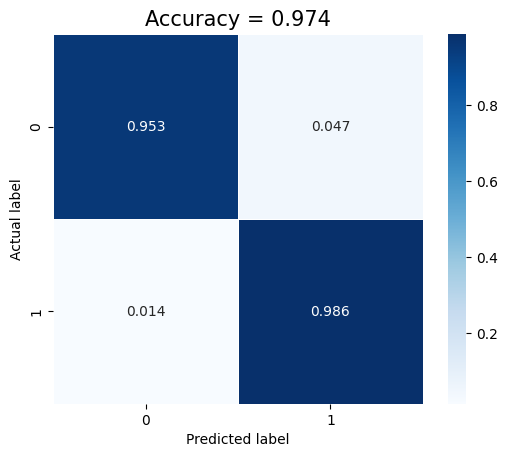

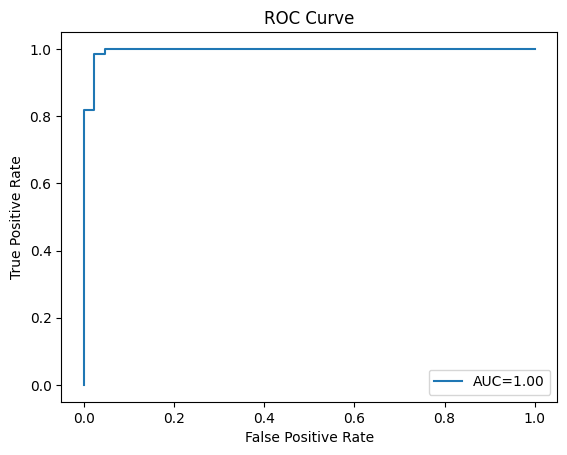

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix


test_loss, test_probs, _, test_trues = evaluate_classification(model, val_loader, criterion) # again, we use validation data only for lab convenience.

# Binary predictions
test_preds = (test_probs > 0.5).astype(int)

# Accuracy
accuracy = accuracy_score(test_trues, test_preds)
print("Test Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(test_trues, test_preds, normalize='true')
# plt.figure(figsize=(9, 9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title(f"Accuracy = {accuracy:.3f}", size=15)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(test_trues, test_probs)
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



## 6) Save model

In [29]:
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'input_dim': nb_input_features
    },
    'bcnet_pytorch.pt'
)

## 7) Load model

In [30]:
model_info = torch.load('bcnet_pytorch.pt')

In [31]:
# Create a new instance of the model and load the state dictionary
model = BCNet(model_info['input_dim'])
model.load_state_dict(model_info['model_state_dict'])
model.eval() # Set the model to evaluation mode

BCNet(
  (fc1): Linear(in_features=30, out_features=30, bias=True)
  (fc2): Linear(in_features=30, out_features=15, bias=True)
  (out): Linear(in_features=15, out_features=1, bias=True)
)